### Feature Engineering

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

In [35]:
df=pd.read_csv('Data/cleaned_car_data.csv')

In [36]:
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [37]:
# 'Car_Age' to capture how old the car is
df['Car_Age'] = 2025 - df['Year']
df['Car_Age'] = df['Car_Age'].replace(0, 1)

#'Mileage_per_Year' for usage intensity
df['Mileage_per_Year'] = (df['Mileage'] / df['Car_Age']).round(2)


In [38]:
# Check the new columns
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Car_Age,Mileage_per_Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320,34,8.15
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212,26,16.42
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500,22,16.27
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7,18,13.33
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4,14,8.57


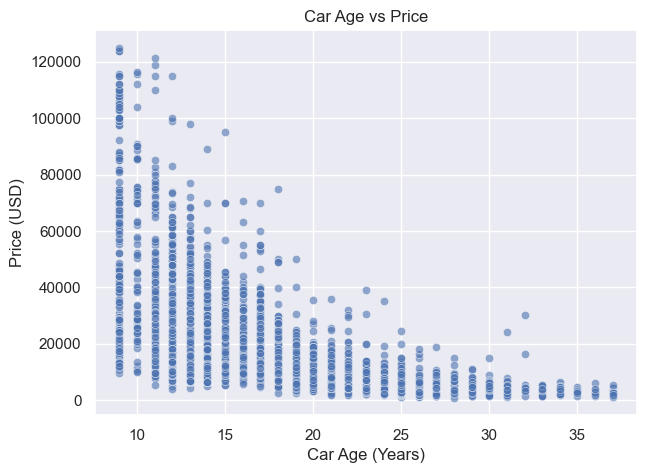

In [39]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Car_Age', y='Price', alpha=0.6)
plt.title("Car Age vs Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price (USD)")
plt.show()


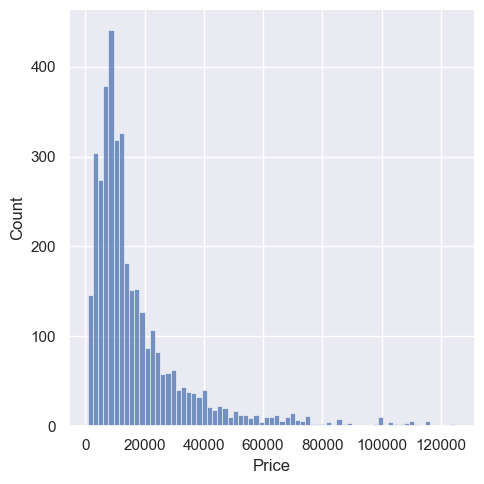

In [40]:
sns.displot(df['Price'])

In [41]:
# we have unstable price distribution so can convert it to log price.

log_price = np.log(df['Price'])

# Then we add it to our data frame
df['log_price'] = log_price
df

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Car_Age,Mileage_per_Year,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320,34,8.15,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212,26,16.42,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500,22,16.27,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7,18,13.33,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4,14,8.57,9.814656
...,...,...,...,...,...,...,...,...,...,...,...,...
3811,Renault,6800.0,sedan,152,1.6,Petrol,yes,2007,Megane,18,8.44,8.824678
3812,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008,T5 (Transporter),17,9.59,9.350102
3813,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,Corolla,11,3.18,9.792556
3814,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535,26,0.04,8.779557


In [42]:
# Identify top-tier luxury/performance brands based on 'Brand vs Log Price' boxplot
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche']

# Create a binary feature: 1 if the car is a luxury brand, 0 otherwise
df['is_luxury'] = df['Brand'].apply(lambda x: 1 if x in luxury_brands else 0)

# Create the interaction term: Luxury Status * Engine Volume
# This feature captures the extra price premium that a large engine provides *only* in a luxury car.
df['Luxury_EngineV_Interaction'] = df['is_luxury'] * df['EngineV'] 

# Keeping 'is_luxury' for potential use as a simple binary feature as well.

print("2. Feature Interaction Complete.")
print("Feature 'Luxury_EngineV_Interaction' created to capture conditional premium.")
print("-" * 50)

2. Feature Interaction Complete.
Feature 'Luxury_EngineV_Interaction' created to capture conditional premium.
--------------------------------------------------


In [43]:
df.head()


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Car_Age,Mileage_per_Year,log_price,is_luxury,Luxury_EngineV_Interaction
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320,34,8.15,8.342840,1,2.0
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212,26,16.42,8.974618,1,2.9
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500,22,16.27,9.495519,1,5.0
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7,18,13.33,10.043249,1,4.2
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4,14,8.57,9.814656,0,0.0


In [44]:
df.to_csv('Data/featured_eng_data.csv', index=False)